# Pronóstico de Ventas Semanales - Walmart
### Prospectiva Tecnológica y Producción Inteligente

**Dataset:** Walmart Recruiting - Store Sales Forecasting (Kaggle)
**Indicador monitoreado:** Weekly_Sales (ventas semanales), como proxy de facturación y demanda.

**Estructura del análisis:**
- Parte 1: análisis macro de las 5 tiendas con mayor volumen de ventas (dashboard en Excel).
- Parte 2 : extensión de Machine Learning a nivel departamento.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.holtwinters import ExponentialSmoothing

## 1. Carga y exploración del dataset

Se carga `train.csv` (~421,570 filas) y se revisan tipos de dato, valores nulos y rango de fechas antes de cualquier análisis.

In [2]:
df = pd.read_csv(r"C:\Users\Mauxy Salcedo\OneDrive\mauxy\train.csv", parse_dates=["Date"])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Store         421570 non-null  int64         
 1   Dept          421570 non-null  int64         
 2   Date          421570 non-null  datetime64[us]
 3   Weekly_Sales  421570 non-null  float64       
 4   IsHoliday     421570 non-null  bool          
dtypes: bool(1), datetime64[us](1), float64(1), int64(2)
memory usage: 13.3 MB


In [3]:
import os
print(os.getcwd())

C:\Users\Mauxy Salcedo\Documents


In [4]:
df.describe()

,Store,Dept,Date,Weekly_Sales
count,421570.000000,421570.000000,421570,421570.000000
mean,22.200546,44.260317,2011-06-18 08:30:31.963375,15981.258123
min,1.000000,1.000000,2010-02-05 00:00:00,-4988.940000
25%,11.000000,18.000000,2010-10-08 00:00:00,2079.650000
50%,22.000000,37.000000,2011-06-17 00:00:00,7612.030000
75%,33.000000,74.000000,2012-02-24 00:00:00,20205.852500
max,45.000000,99.000000,2012-10-26 00:00:00,693099.360000
std,12.785297,30.492054,NaN,22711.183519


## 2. Selección de las 5 tiendas con mayor volumen de ventas

Criterio de selección: únicamente volumen total de ventas (`Weekly_Sales` sumado por tienda). No se filtra por valores negativos o en cero en este paso, porque al sumar todos los departamentos de una tienda es prácticamente imposible que el total dé cero.

**Resultado:** las 5 tiendas con mayor venta total son la 20, 4, 14, 13 y 2 — todas con las 143 semanas completas de historia.

In [5]:
resumen = df.groupby("Store").agg(
    n_semanas=("Date", "nunique"),
    ventas_totales=("Weekly_Sales", "sum"),
    ventas_negativas=("Weekly_Sales", lambda x: (x < 0).sum()),
    ventas_cero=("Weekly_Sales", lambda x: (x == 0).sum()),
).sort_values("ventas_totales", ascending=False)

resumen

,n_semanas,ventas_totales,ventas_negativas,ventas_cero
Store,,,,
20,143,3.013978e+08,38,3
4,143,2.995440e+08,5,0
14,143,2.889999e+08,32,3
13,143,2.865177e+08,15,2
2,143,2.753824e+08,22,2
10,143,2.716177e+08,50,5
27,143,2.538559e+08,27,2
6,143,2.237561e+08,21,1
1,143,2.224028e+08,15,3


In [6]:
top5 = [20, 4, 14, 13, 2]

df_top5 = df[df["Store"].isin(top5)]
ventas_semanales_top5 = df_top5.groupby(["Store", "Date"])["Weekly_Sales"].sum().reset_index()

ventas_semanales_top5.head()

,Store,Date,Weekly_Sales
0,2,2010-02-05,2136989.46
1,2,2010-02-12,2137809.50
2,2,2010-02-19,2124451.54
3,2,2010-02-26,1865097.27
4,2,2010-03-05,1991013.13


## 3. Comparación visual de tendencia y estacionalidad
Se grafican las 5 series semanales juntas para identificar tendencia general y patrones que se repiten cada año (estacionalidad).

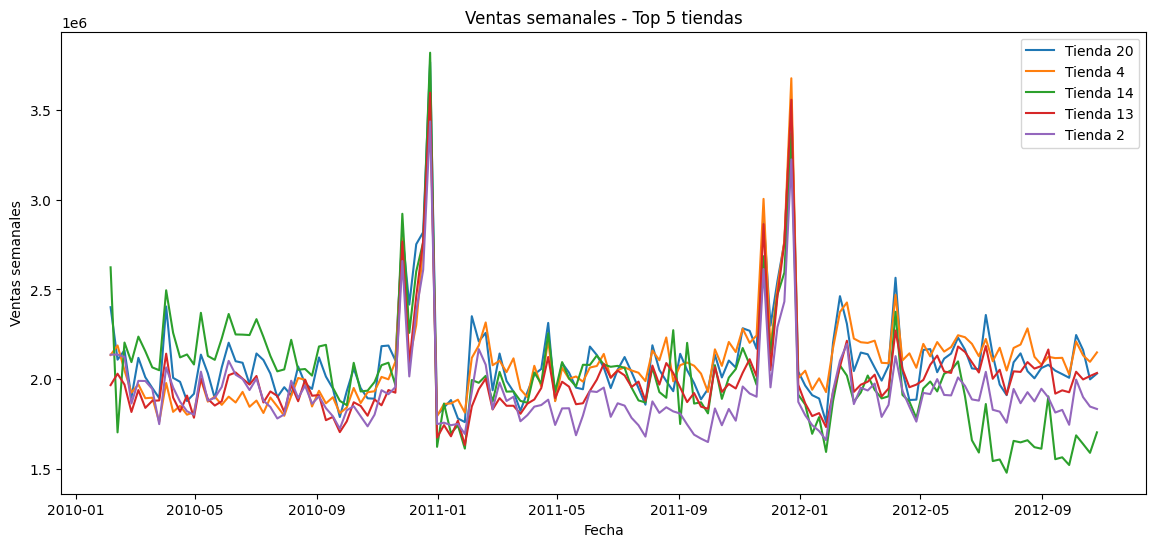

In [7]:
plt.figure(figsize=(14, 6))

for store in top5:
    datos_tienda = ventas_semanales_top5[ventas_semanales_top5["Store"] == store]
    plt.plot(datos_tienda["Date"], datos_tienda["Weekly_Sales"], label=f"Tienda {store}")

plt.title("Ventas semanales - Top 5 tiendas")
plt.xlabel("Fecha")
plt.ylabel("Ventas semanales")
plt.legend()
plt.show()

## 4. Efecto de los feriados en las ventas

Se compara el promedio de ventas semanales entre semanas normales y semanas marcadas como feriado (`IsHoliday`).

In [8]:
df_top5.groupby("IsHoliday")["Weekly_Sales"].mean()

IsHoliday
False    28216.686710
True     29897.707274
Name: Weekly_Sales, dtype: float64

## 5. Desglose por tipo de feriado y hallazgo sobre "Navidad"

El promedio general de `IsHoliday` (True vs False) diluye el efecto real, porque mezcla 4 feriados muy distintos (Súper Tazón, Día del Trabajo, Acción de Gracias, Navidad). Se separa el promedio por cada uno.

**Hallazgo:** la semana marcada como "Navidad" en el dataset (ej. 2010-12-31) tiene ventas *por debajo* del promedio normal — no arriba, como se esperaría. Al revisar semana a semana, se confirma que el pico real de compras navideñas ocurre la semana previa (2010-12-24), que el dataset NO marca como feriado. Es decir, `IsHoliday` captura la semana post-Navidad (de descanso), no la de mayor demanda.

In [9]:
fechas_feriados = {
    "2010-02-12": "Super Bowl", "2011-02-11": "Super Bowl", "2012-02-10": "Super Bowl",
    "2010-09-10": "Dia del Trabajo", "2011-09-09": "Dia del Trabajo", "2012-09-07": "Dia del Trabajo",
    "2010-11-26": "Accion de Gracias", "2011-11-25": "Accion de Gracias", "2012-11-23": "Accion de Gracias",
    "2010-12-31": "Navidad", "2011-12-30": "Navidad", "2012-12-28": "Navidad",
}

df_top5 = df_top5.copy()
df_top5["Feriado"] = df_top5["Date"].dt.strftime("%Y-%m-%d").map(fechas_feriados)
df_top5["Feriado"] = df_top5["Feriado"].fillna("Semana normal")

df_top5.groupby("Feriado")["Weekly_Sales"].mean().sort_values(ascending=False)

Feriado
Accion de Gracias    38758.781245
Super Bowl           29181.985726
Semana normal        28216.686710
Dia del Trabajo      27591.010231
Navidad              25556.555014
Name: Weekly_Sales, dtype: float64

In [10]:
ventas_semanales_top5[
    (ventas_semanales_top5["Date"] >= "2010-12-10") &
    (ventas_semanales_top5["Date"] <= "2011-01-07")
].groupby("Date")["Weekly_Sales"].sum()

Date
2010-12-10    12495341.10
2010-12-17    13702925.28
2010-12-24    18143998.15
2010-12-31     8644049.54
2011-01-07     9072848.50
Name: Weekly_Sales, dtype: float64

## 6. Pronóstico con Holt-Winters

Se separan los datos en entrenamiento (train) y prueba (test) por fecha — nunca de forma aleatoria, porque mezclar fechas al azar generaría fuga de datos (el modelo "vería el futuro" al entrenarse).

Se aplica suavizado exponencial (Holt-Winters) a cada una de las 5 tiendas por separado, con `seasonal_periods=52` para capturar el ciclo anual. **Limitación conocida:** solo hay ~143 semanas de historia total, así que el modelo apenas alcanza a ver poco más de 2 ciclos anuales completos — esto afecta la precisión del ajuste estacional.

In [11]:
punto_corte = "2012-06-01"

train = ventas_semanales_top5[ventas_semanales_top5["Date"] < punto_corte]
test = ventas_semanales_top5[ventas_semanales_top5["Date"] >= punto_corte]

print("Train:", train["Date"].min(), "a", train["Date"].max())
print("Test:", test["Date"].min(), "a", test["Date"].max())
print("Semanas en train:", train["Date"].nunique(), "| Semanas en test:", test["Date"].nunique())

Train: 2010-02-05 00:00:00 a 2012-05-25 00:00:00
Test: 2012-06-01 00:00:00 a 2012-10-26 00:00:00
Semanas en train: 121 | Semanas en test: 22


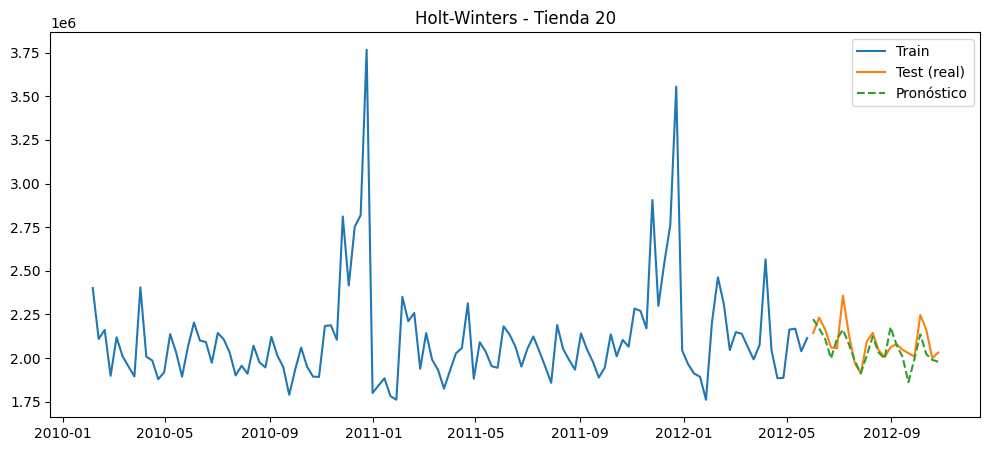

In [12]:
tienda_ejemplo = 20

train_tienda = train[train["Store"] == tienda_ejemplo].set_index("Date")["Weekly_Sales"]
train_tienda = train_tienda.asfreq("W-FRI")  # frecuencia semanal, viernes (día de las fechas del dataset)

test_tienda = test[test["Store"] == tienda_ejemplo].set_index("Date")["Weekly_Sales"]
test_tienda = test_tienda.asfreq("W-FRI")

modelo = ExponentialSmoothing(
    train_tienda,
    trend="add",
    seasonal="add",
    seasonal_periods=52
).fit()

pronostico = modelo.forecast(len(test_tienda))

plt.figure(figsize=(12, 5))
plt.plot(train_tienda.index, train_tienda.values, label="Train")
plt.plot(test_tienda.index, test_tienda.values, label="Test (real)")
plt.plot(test_tienda.index, pronostico.values, label="Pronóstico", linestyle="--")
plt.title(f"Holt-Winters - Tienda {tienda_ejemplo}")
plt.legend()
plt.show()

In [13]:
error = test_tienda.values - pronostico.values

MAD = np.mean(np.abs(error))
MSE = np.mean(error**2)
MAPE = np.mean(np.abs(error / test_tienda.values)) * 100

print(f"MAD:  {MAD:,.2f}")
print(f"MSE:  {MSE:,.2f}")
print(f"MAPE: {MAPE:.2f}%")

MAD:  61,673.79
MSE:  6,644,091,559.88
MAPE: 2.88%


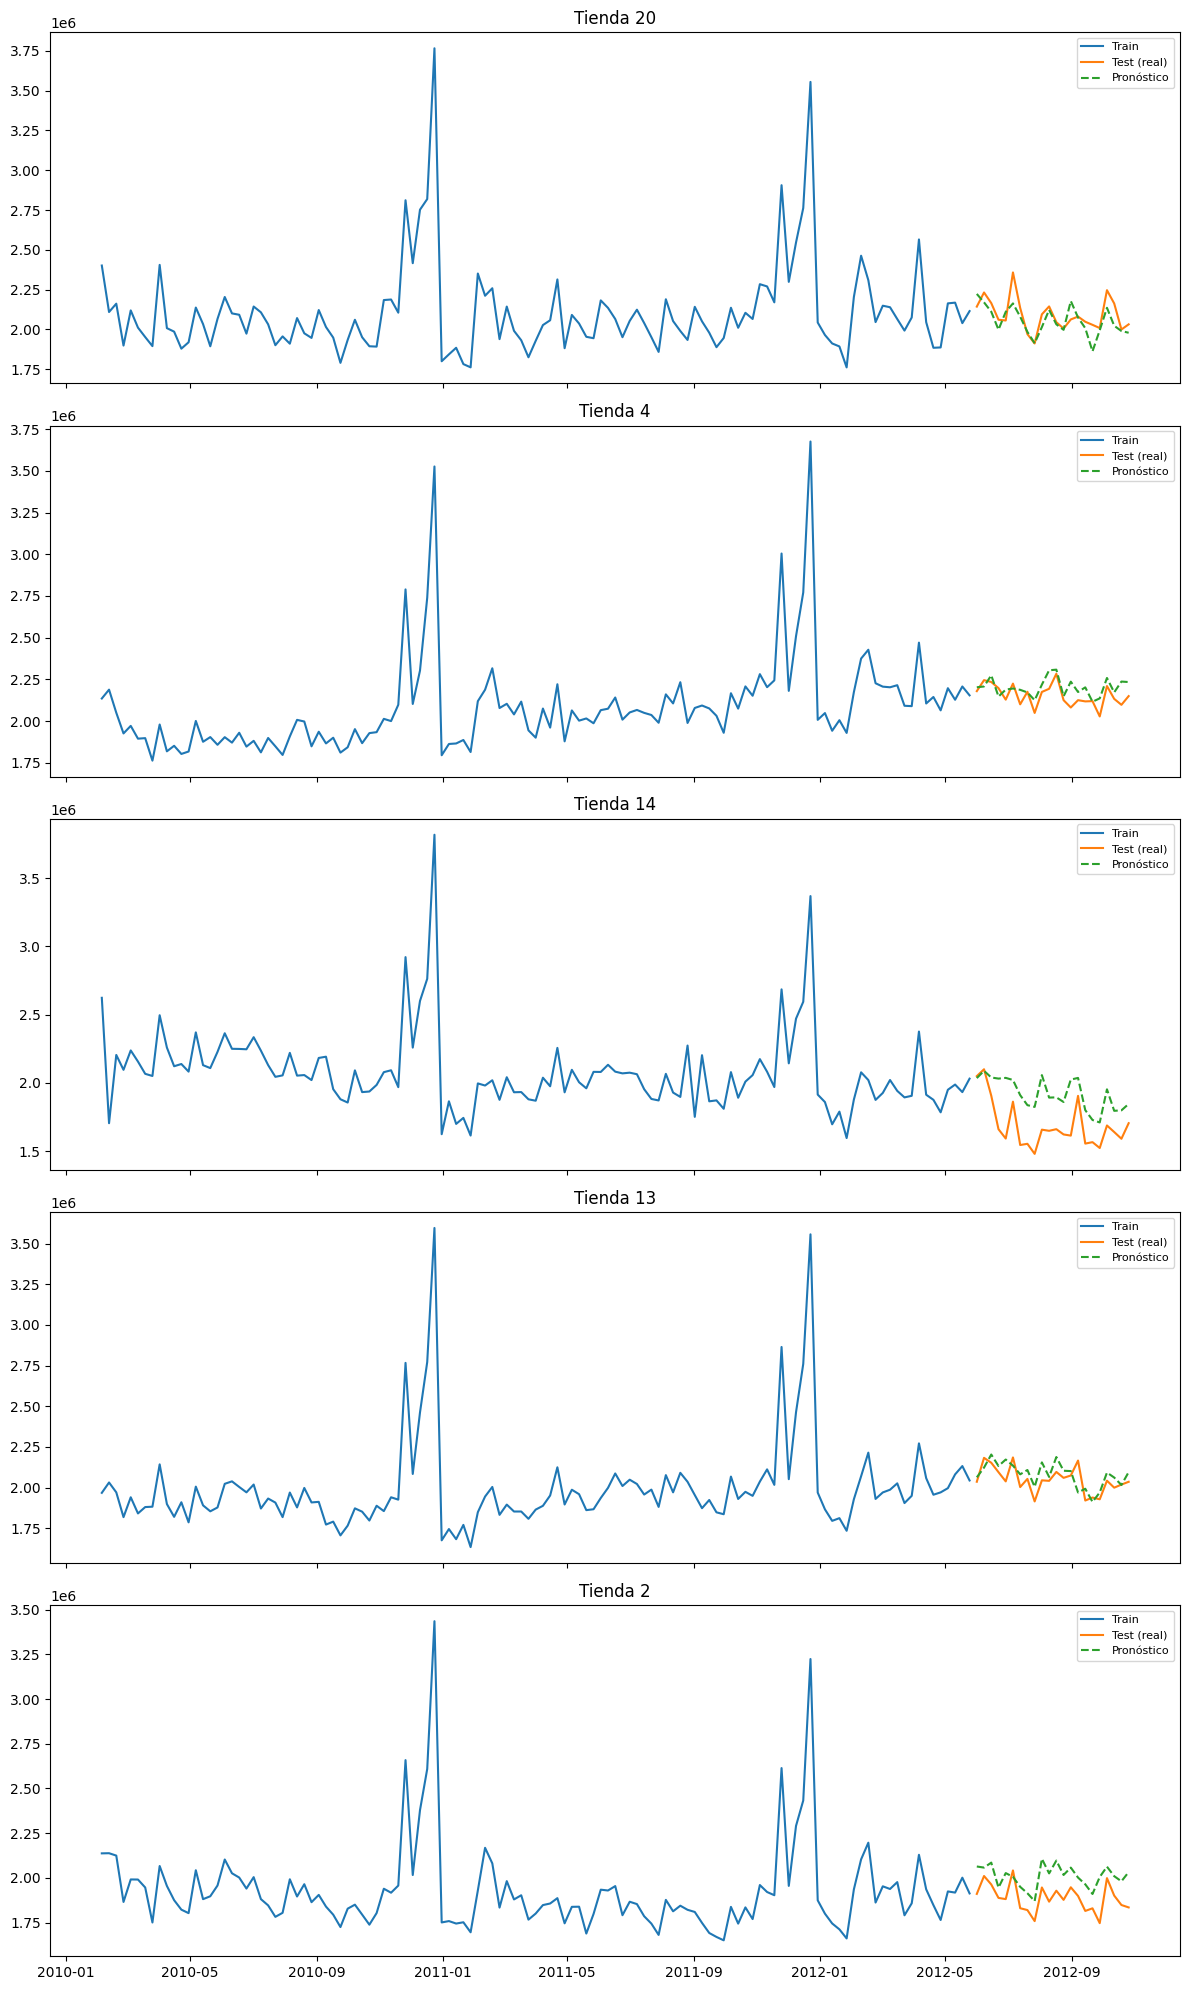

,Store,MAD ($),MSE,RMSE ($),MAPE (%)
0,20,"61,674","6,644,091,560","81,511",2.88
1,4,"60,118","5,232,757,546","72,338",2.82
2,14,"234,056","68,487,745,074","261,702",14.42
3,13,"63,274","5,734,617,925","75,727",3.08
4,2,"123,525","17,795,108,876","133,398",6.61


In [14]:
resultados_hw = []

fig, axes = plt.subplots(5, 1, figsize=(12, 20), sharex=True)

for i, store in enumerate(top5):
    train_t = train[train["Store"] == store].set_index("Date")["Weekly_Sales"].asfreq("W-FRI")
    test_t = test[test["Store"] == store].set_index("Date")["Weekly_Sales"].asfreq("W-FRI")

    modelo_t = ExponentialSmoothing(
        train_t, trend="add", seasonal="add", seasonal_periods=52
    ).fit()
    pronostico_t = modelo_t.forecast(len(test_t))

    error_t = test_t.values - pronostico_t.values
    mad_t = np.mean(np.abs(error_t))
    mse_t = np.mean(error_t**2)
    rmse_t = np.sqrt(mse_t)
    mape_t = np.mean(np.abs(error_t / test_t.values)) * 100

    resultados_hw.append({
        "Store": store, "MAD ($)": mad_t, "MSE": mse_t,
        "RMSE ($)": rmse_t, "MAPE (%)": mape_t
    })

    ax = axes[i]
    ax.plot(train_t.index, train_t.values, label="Train")
    ax.plot(test_t.index, test_t.values, label="Test (real)")
    ax.plot(test_t.index, pronostico_t.values, label="Pronóstico", linestyle="--")
    ax.set_title(f"Tienda {store}")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

resultados_hw = pd.DataFrame(resultados_hw)
resultados_hw.style.format({
    "MAD ($)": "{:,.0f}",
    "MSE": "{:,.0f}",
    "RMSE ($)": "{:,.0f}",
    "MAPE (%)": "{:.2f}"
})

## 7. Conclusiones - Parte 1

**Tendencia y estacionalidad:** las 5 tiendas con mayor volumen (20, 4, 14, 13, 2) muestran un patrón estacional claro y consistente entre sí, con dos picos anuales marcados en la temporada de fin de año.

**Efecto de feriados:** el promedio general de `IsHoliday` (True vs False) resulta engañoso, porque mezcla 4 feriados de impacto muy distinto. Al desglosar por tipo, se encontró que la semana etiquetada como "Navidad" en el dataset en realidad corresponde a la semana *posterior* a la Navidad (ventas ya en descenso), mientras que el pico real de compras ocurre la semana previa, que el dataset no marca como feriado. Esta es una particularidad del etiquetado del dataset, relevante para no interpretar mal la variable `IsHoliday` en futuros análisis.

**Pronóstico (Holt-Winters):** el modelo tuvo un desempeño sólido en 4 de las 5 tiendas (MAPE entre 2.8% y 6.6%). La excepción fue la Tienda 14, con un MAPE de 14.4%, que coincide con un cambio real de tendencia observado en el análisis visual (pasó de ser la tienda líder en 2010 a caer por debajo de las demás hacia 2012) — un comportamiento que un modelo de tendencia lineal simple no logra capturar completamente.

**Limitación general:** el dataset cubre solo ~143 semanas por tienda (~2.75 años), lo cual limita el ajuste del componente estacional anual (`seasonal_periods=52`), que idealmente requeriría 104+ semanas para un ajuste más robusto.

In [15]:
resultados = ventas_semanales_top5.copy()
resultados.to_excel("resultados_top5_tiendas.xlsx", index=False, sheet_name="Datos")

print("Archivo guardado:", os.getcwd())

Archivo guardado: C:\Users\Mauxy Salcedo\Documents
